# Setup


In [1]:
import pandas as pd
import json
import os
import glob
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import simpledorff
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

In [2]:
# --- FILE AND FOLDER PATHS ---
MANUAL_ANNOTATIONS_FOLDER = "../prolific_annotations/"
NEW_MANUAL_ANNOTATIONS_FILE = "../prolific_annotations/prolific_all_annotations.csv" 
PAPER_SECTIONS_FILE = "../prolific_annotations/paper_sections.csv"
LLM_OUTPUT_FOLDER = "../llm_annotations/output/"
ORIGINAL_DATA_FILE = "../llm_annotations/auto_eval_sample.parquet"

# --- KEY COLUMN NAMES ---
ALGORITHM_LABEL_COL = 'sec_label_extended'

# Human annotations

In [3]:
print("🔍 Loading and preparing new human annotation data...")

# 1. Load the new annotations
manual_df = pd.read_csv(NEW_MANUAL_ANNOTATIONS_FILE)

# 2. Filter for annotator_id >= 69
manual_df = manual_df[manual_df['annotator_id'] >= 69]

# 3. Rename 'paper_id' to 'corpusid' to maintain consistency with the rest of your notebook
manual_df = manual_df.rename(columns={'paper_id': 'corpusid', 'label': 'manual_label'})

# 4. Load paper sections to get the 'start' position
sections_df = pd.read_csv(PAPER_SECTIONS_FILE)

# 5. Merge to get the 'start' position (using section_id and paper_id)
# Note: 'id' in paper_sections.csv corresponds to 'section_id' in your annotations
manual_df = pd.merge(
    manual_df, 
    sections_df[['id', 'start_position']], 
    left_on='section_id', 
    right_on='id', 
    how='left'
)

# Rename 'start_position' to 'start'
manual_df = manual_df.rename(columns={'start_position': 'start'})

# 6. Cleanup extra columns and ensure 'annotator' column exists (using annotator_id)
manual_df['annotator'] = manual_df['annotator_id'].astype(str)
manual_df = manual_df.drop(columns=['id_y', 'annotator_id', 'created_at']) # removing redundant id from sections_df

print(f"✅ Successfully loaded {len(manual_df)} manual annotations.")
manual_df

🔍 Loading and preparing new human annotation data...
✅ Successfully loaded 3639 manual annotations.


,id_x,corpusid,section_id,manual_label,is_other_language,is_annotator_confused,start,annotator
0,3420,11809862,147,introduction,0,0,2440,69
1,3421,11809862,148,introduction,0,0,3688,69
2,3422,11809862,149,introduction,0,0,5016,69
3,3423,11809862,150,introduction,0,0,6160,69
4,3424,11809862,151,introduction,0,0,6823,69
...,...,...,...,...,...,...,...,...
3634,7460,29775388,1129,discussion,0,0,57120,131
3635,7461,29775388,1130,discussion,0,0,60725,131
3636,7462,29775388,1131,discussion,0,0,63415,131
3637,7463,29775388,1132,conclusion,0,0,67917,131


## Calculate inter-annotator agreement
The annotation used a staggered approach, so a few items were double-annotated. We can use those to calculate agreement.

In [4]:
# Remove rows where the paper is in another language, the annotator was confused, or did not attribute a label
manual_df_filtered = manual_df[
    (manual_df['corpusid'] != 234586248) & # Paper not in English
    (manual_df['corpusid'] != 86268276) & # Paper not in English
    #(manual_df['is_other_language'] == 0) & # In fact, the interface didn't save these values properly, so they're all 0
    #(manual_df['is_annotator_confused'] == 0) & # In fact, the interface didn't save these values properly, so they're all 0
    (manual_df['manual_label'].notna())
]

In [5]:
import simpledorff

# Your 'section_id' is the unit, 'annotator' is the coder, 'manual_label' is the value
alpha = simpledorff.calculate_krippendorffs_alpha_for_df(
    manual_df_filtered, 
    experiment_col='section_id', 
    annotator_col='annotator', 
    class_col='manual_label'
)

print(f"Krippendorff's Alpha: {alpha}")

Krippendorff's Alpha: 0.6092291833839046


## Consensus annotations
Exclude rows where annotators disagreed

In [6]:
item_identifier = ['corpusid', 'start']

print(f"Total unique items annotated: {manual_df_filtered.groupby(item_identifier).ngroups}")

# Group by each item and check the labels
# We use .agg() to get both the count of annotations and the number of unique labels
label_agg = manual_df_filtered.groupby(item_identifier)['manual_label'].agg(
    annotation_count='size', # How many people annotated it
    unique_labels='nunique', # How many different labels were given
    manual_label='first' # Get the actual label (it will be the same for all in the group)
).reset_index()

# Filter to keep only items with unambiguous agreement
# This means we only want groups where the number of unique labels is 1.
# This single condition cleverly handles both cases:
# 1. One annotation (unique_labels will be 1)
# 2. Two annotations that are the same (unique_labels will still be 1)
consensus_annotations = label_agg[label_agg['unique_labels'] == 1].copy()

# We no longer need the intermediate columns
consensus_annotations = consensus_annotations[item_identifier + ['manual_label']]

print(f"Items with clear agreement (ground truth): {len(consensus_annotations)}")

consensus_annotations

Total unique items annotated: 1213
Items with clear agreement (ground truth): 698


,corpusid,start,manual_label
0,832325,1892,introduction
1,832325,4721,results
4,832325,14060,results
5,832325,14316,results
6,832325,15009,results
...,...,...,...
1202,276810708,11357,results
1204,276810708,13721,discussion
1205,276810708,22021,methods
1206,276810708,23298,methods


In [7]:
# --- REVISED CONSENSUS LOGIC (MAJORITY VOTING) ---
item_identifier = ['corpusid', 'start']

print(f"Total unique items annotated: {manual_df_filtered.groupby(item_identifier).ngroups}")

# 1. Group by item and label to get counts per label
counts = manual_df_filtered.groupby(item_identifier + ['manual_label']).size().reset_index(name='count')

# 2. Sort so the highest count for each item is first
counts = counts.sort_values(item_identifier + ['count'], ascending=[True, True, False])

# 3. Get the top label and its count
consensus_df = counts.groupby(item_identifier).head(1).copy()

# 4. Get the total number of annotators for each item to check for a majority
total_counts = manual_df_filtered.groupby(item_identifier).size().reset_index(name='total_votes')

# 5. Merge back and filter for majority agreement (> 50%)
consensus_df = pd.merge(consensus_df, total_counts, on=item_identifier)
consensus_annotations = consensus_df[consensus_df['count'] > (consensus_df['total_votes'] / 2)].copy()

# Cleanup
consensus_annotations = consensus_annotations[item_identifier + ['manual_label']]

print(f"Items with majority agreement (ground truth): {len(consensus_annotations)}")
consensus_annotations.head()

Total unique items annotated: 1213
Items with majority agreement (ground truth): 1074


,corpusid,start,manual_label
0,832325,1892,introduction
1,832325,4721,results
4,832325,14060,results
5,832325,14316,results
6,832325,15009,results


# LLM annotations

In [8]:
print("🔍 Parsing LLM batch output files...")

# Find all text files in the output folder
llm_files = glob.glob(os.path.join(LLM_OUTPUT_FOLDER, "*.txt"))

if not llm_files:
    raise FileNotFoundError(f"No .txt files found in '{LLM_OUTPUT_FOLDER}'. Please check the path.")

llm_results = []
for file_path in llm_files:
    with open(file_path, 'r') as f:
        for line in f:
            try:
                # Load the outer JSON object
                data = json.loads(line)

                # Skip if the API call resulted in an error
                if data.get('error') is not None:
                    continue

                custom_id = data['custom_id']
                
                # Navigate the nested structure to get to the output text
                response_body = data['response']['body']
                output_text_str = response_body['output'][1]['content'][0]['text']
                
                # The output text itself is a JSON string, so we parse it again
                output_data = json.loads(output_text_str)

                llm_results.append({
                    'custom_id': custom_id,
                    'llm_label': output_data['label'],
                    'llm_confidence': output_data['confidence']
                })

            except (json.JSONDecodeError, KeyError, IndexError) as e:
                print(f"  - Warning: Could not parse a line in {os.path.basename(file_path)}. Error: {e}")

# Create the final DataFrame for the LLM annotations
llm_df = pd.DataFrame(llm_results)

print(f"✅ Successfully parsed {len(llm_df)} results from {len(llm_files)} LLM output files.")
llm_df

🔍 Parsing LLM batch output files...
  - Warning: Could not parse a line in 5.txt. Error: Unterminated string starting at: line 1 column 10 (char 9)
✅ Successfully parsed 16166 results from 9 LLM output files.


,custom_id,llm_label,llm_confidence
0,189755-0,introduction,high
1,189755-1,lit_review,high
2,189755-2,introduction,high
3,189755-3,methods,high
4,189755-4,methods,high
...,...,...,...
16161,54062190-12,discussion,high
16162,54062190-13,discussion,high
16163,54062190-14,conclusion,high
16164,54082575-0,introduction,high


# Merging the data into one dataframe

In [9]:
print("🔍 Loading original data from Parquet file...")
original_df = pd.read_parquet(ORIGINAL_DATA_FILE)

# --- Prepare Join Key for LLM Data ---
# Re-create the 'custom_id' exactly as it was made in the batch script.
# This consists of the paper's ID and its intra-document section index.
print("🔧 Creating 'custom_id' join key...")
original_df['doc_index'] = original_df.groupby('corpusid').cumcount()
original_df['custom_id'] = original_df['corpusid'].astype(str) + '-' + original_df['doc_index'].astype(str)

print("✅ Original data loaded and keys prepared.")
original_df

🔍 Loading original data from Parquet file...
🔧 Creating 'custom_id' join key...
✅ Original data loaded and keys prepared.


,corpusid,start,end_header,end_section,extracted,section_text,sec_label_extended,doc_index,custom_id
0,1936834,2946,3013,7096,evaluation of recombinant antigens for chagas ...,EVALUATION OF RECOMBINANT ANTIGENS FOR CHAGAS ...,results,0,1936834-0
1,1936834,7096,7244,10140,"differential diagnosis of acute, congeni-tal a...","DIFFERENTIAL DIAGNOSIS OF ACUTE, CONGENI-TAL A...",results,1,1936834-1
2,2148051,2190,2202,4250,introduction,INTRODUCTION\n\nGlaucoma is the most important...,introduction,0,2148051-0
3,2148051,4250,4280,6297,goldmann applanation tonometer,GOLDMANN APPLANATION TONOMETER\n\nDeveloped in...,introduction,1,2148051-1
4,2148051,6297,6323,7044,perkins handheld tonometer,Perkins Handheld Tonometer\n\nThe Perkins tono...,introduction,2,2148051-2
...,...,...,...,...,...,...,...,...,...
27023,272327929,27059,27069,27395,figure 6 .,FIguRE 6 .\n6\nFIguRE 6. Overall survival anal...,figure_table,22,272327929-22
27024,272327929,27395,27405,27737,figure 7 .,FIguRE 7 .\n7\nFIguRE 7. Disease-specific surv...,figure_table,23,272327929-23
27025,272327929,27737,27747,28107,figure 8 .,FIguRE 8 .\n8\nFIguRE 8. Progression-free inte...,figure_table,24,272327929-24
27026,272327929,28107,28118,28386,figure 10 .,FIguRE 10 .\n10\nFIguRE 10.Enrichment analyses...,figure_table,25,272327929-25


In [10]:
# --- Merge 1: Join with LLM Annotations ---
# We use the 'custom_id' column as the key.
print("🤝 Merging original data with LLM annotations...")
combined_df = pd.merge(
    original_df,
    llm_df,
    on='custom_id',
    how='left'
)
print(f"Shape after merging with LLM data: {combined_df.shape}")


# --- Merge 2: Join with Human Consensus Annotations ---
# We use 'corpusid' and 'start' as the keys.
print("🤝 Merging result with human consensus annotations...")
final_df = pd.merge(
    combined_df,
    consensus_annotations,
    on=['corpusid', 'start'],
    how='left'
)
print(f"Shape after merging with human data: {final_df.shape}")
print("✅ All merges complete.")

final_df = final_df.rename(columns={'sec_label_extended': 'classification_label'})

final_df[[
    'corpusid',
    'start',
    'classification_label', # Classifier prediction
    'llm_label',           # LLM's prediction
    'manual_label'         # Human consensus label
]]

🤝 Merging original data with LLM annotations...
Shape after merging with LLM data: (32429, 11)
🤝 Merging result with human consensus annotations...
Shape after merging with human data: (32429, 12)
✅ All merges complete.


,corpusid,start,classification_label,llm_label,manual_label
0,1936834,2946,results,methods,NaN
1,1936834,7096,results,methods,NaN
2,2148051,2190,introduction,introduction,NaN
3,2148051,4250,introduction,lit_review,NaN
4,2148051,6297,introduction,lit_review,NaN
...,...,...,...,...,...
32424,272327929,27059,figure_table,NaN,NaN
32425,272327929,27395,figure_table,NaN,NaN
32426,272327929,27737,figure_table,NaN,NaN
32427,272327929,28107,figure_table,NaN,NaN


In [11]:
# Filtering out irrelevant sections (not annotated)
final_df = final_df[~final_df['classification_label'].isin(['figure_table', 'ending', 'other'])]

# Remove rows with only one classification label
final_df = final_df[final_df[['classification_label', 'llm_label', 'manual_label']].notna().sum(axis=1) > 1]

# Keep only relevant columns
eval_df = final_df[[
    'corpusid',
    'start',
    'classification_label', # Classifier prediction
    'llm_label',           # LLM's prediction
    'manual_label'         # Human consensus label
]]
eval_df


,corpusid,start,classification_label,llm_label,manual_label
0,1936834,2946,results,methods,NaN
1,1936834,7096,results,methods,NaN
2,2148051,2190,introduction,introduction,NaN
3,2148051,4250,introduction,lit_review,NaN
4,2148051,6297,introduction,lit_review,NaN
...,...,...,...,...,...
32174,263372833,16424,development,NaN,methods
32175,263372833,16634,development,NaN,methods
32176,263372833,16634,development,NaN,methods
32179,263372833,16925,development,NaN,conclusion


# Evaluations

> **Label handling note:** `something_else`, `ambiguous`, and `case_report` were not part of the classifier's label set — they were added later for human/LLM annotation. These are **excluded from all agreement metrics** to ensure fair comparison across rater types. They are kept in confusion matrices and heatmaps so it's visible how often humans and LLMs used them. `development` and `lit_review` were available to the classifier and are kept in metrics as-is.

In [12]:
ALGORITHM_LABEL_COL = 'classification_label'

# Labels unavailable to the classifier — excluded from metrics, kept in visualizations
CLASSIFIER_UNSUPPORTED_LABELS = ['something_else', 'ambiguous', 'case_report']

# Full label order for visualizations (includes unsupported labels)
MASTER_LABEL_ORDER = [
    'introduction', 'lit_review', 'case_report', 'development',
    'methods', 'results', 'discussion', 'conclusion',
    'something_else', 'ambiguous'
]

# Label order for metrics only
METRICS_LABEL_ORDER = [l for l in MASTER_LABEL_ORDER if l not in CLASSIFIER_UNSUPPORTED_LABELS]

def filter_for_metrics(df, *cols):
    """Remove rows where any of the given columns contain a classifier-unsupported label."""
    mask = df[list(cols)].isin(CLASSIFIER_UNSUPPORTED_LABELS).any(axis=1)
    filtered = df[~mask].copy()
    n_removed = mask.sum()
    if n_removed:
        print(f"  Excluded {n_removed} rows containing unsupported labels {CLASSIFIER_UNSUPPORTED_LABELS}")
    return filtered


## 1. Classification metrics

Rows where either the human or LLM label is one of the classifier-unsupported labels (`something_else`, `ambiguous`, `case_report`) are dropped before computing any metrics, so precision/recall/F1 and macro averages are not distorted by categories the classifier could never predict.

In [13]:
from sklearn.metrics import classification_report, cohen_kappa_score

def classification_metrics(df, true_col, pred_col, title):
    """
    Print a classification report after dropping rows with classifier-unsupported labels.
    Returns the filtered dataframe for reuse.
    """
    # Drop rows where either column is NaN
    df = df.dropna(subset=[true_col, pred_col])
    # Drop rows containing unsupported labels
    df = filter_for_metrics(df, true_col, pred_col)

    print(f"--- {title} (n={len(df)}) ---")
    present = set(df[true_col].unique()) | set(df[pred_col].unique())
    ordered_labels = [l for l in METRICS_LABEL_ORDER if l in present]
    print(classification_report(df[true_col], df[pred_col], labels=ordered_labels, zero_division=0))
    return df

df_hc = classification_metrics(eval_df, 'manual_label', ALGORITHM_LABEL_COL, "Human vs. Classifier")
df_hl = classification_metrics(eval_df, 'manual_label', 'llm_label',          "Human vs. LLM")
df_lc = classification_metrics(eval_df, 'llm_label',    ALGORITHM_LABEL_COL,  "LLM vs. Classifier")


  Excluded 41 rows containing unsupported labels ['something_else', 'ambiguous', 'case_report']
--- Human vs. Classifier (n=1485) ---
              precision    recall  f1-score   support

introduction       0.66      0.88      0.75       152
  lit_review       0.56      0.07      0.12       130
 development       0.11      0.79      0.19        34
     methods       0.86      0.73      0.79       508
     results       0.86      0.66      0.75       428
  discussion       0.74      0.82      0.78       137
  conclusion       0.87      0.98      0.92        96

    accuracy                           0.69      1485
   macro avg       0.67      0.71      0.62      1485
weighted avg       0.79      0.69      0.71      1485

  Excluded 42 rows containing unsupported labels ['something_else', 'ambiguous', 'case_report']
--- Human vs. LLM (n=816) ---
              precision    recall  f1-score   support

introduction       0.88      0.86      0.87        92
  lit_review       0.73      0.53 

## 2. Inter-annotator agreement (Krippendorff's Alpha)

All four comparisons use Krippendorff's Alpha so results are on the same scale and directly comparable. Alpha handles missing data natively — no balanced design required. Each human annotator is treated as an individual rater.

Classifier-unsupported labels are excluded from all calculations.

| Comparison | Items used |
|---|---|
| Human vs. Human | Items with ≥2 human annotations |
| Human vs. LLM | Items annotated by ≥1 human and the LLM |
| Human vs. Classifier | Items annotated by ≥1 human and the classifier |
| LLM vs. Classifier | Items annotated by both |

In [14]:
import simpledorff

def krippendorff_alpha_long(long_df, item_col, annotator_col, label_col):
    """Compute Krippendorff's Alpha from a long-format dataframe."""
    clean = long_df.dropna(subset=[label_col])
    if clean[annotator_col].nunique() < 2 or clean[item_col].nunique() < 2:
        return float('nan')
    return simpledorff.calculate_krippendorffs_alpha_for_df(
        clean, experiment_col=item_col, annotator_col=annotator_col, class_col=label_col
    )

def filter_unsupported(df):
    """Remove rows with classifier-unsupported labels."""
    return df[~df['label'].isin(CLASSIFIER_UNSUPPORTED_LABELS)]

# Re-attach section_id to eval_df via corpusid+start
section_ids = manual_df_filtered[['corpusid', 'start', 'section_id']].drop_duplicates()
eval_sid = pd.merge(eval_df, section_ids, on=['corpusid', 'start'], how='left')

# Build long-format tables per rater type
human_long = manual_df_filtered[['section_id', 'annotator', 'manual_label']].copy()
human_long.columns = ['section_id', 'annotator', 'label']

llm_long = eval_sid[['section_id', 'llm_label']].dropna().copy()
llm_long['annotator'] = 'llm'
llm_long = llm_long.rename(columns={'llm_label': 'label'})

algo_long = eval_sid[['section_id', ALGORITHM_LABEL_COL]].dropna().copy()
algo_long['annotator'] = 'classifier'
algo_long = algo_long.rename(columns={ALGORITHM_LABEL_COL: 'label'})

all_long = pd.concat([human_long, llm_long, algo_long], ignore_index=True)

# Precompute item sets for reuse in Option B
multi_human_items = human_long.groupby('section_id')['annotator'].nunique()
multi_human_items = multi_human_items[multi_human_items >= 2].index
hl_items = set(human_long['section_id']) & set(llm_long['section_id'])
hc_items = set(human_long['section_id']) & set(algo_long['section_id'])
lc_items = set(llm_long['section_id']) & set(algo_long['section_id'])
human_annotators = list(human_long['annotator'].unique())

# --- Option A: filter unsupported labels from ALL pairs for direct comparability ---
results = {}

hh_a = filter_unsupported(human_long[human_long['section_id'].isin(multi_human_items)])
results['Human vs. Human'] = (krippendorff_alpha_long(hh_a, 'section_id', 'annotator', 'label'), hh_a['section_id'].nunique())

hl_a = filter_unsupported(all_long[
    all_long['section_id'].isin(hl_items) &
    all_long['annotator'].isin(human_annotators + ['llm'])
])
results['Human vs. LLM'] = (krippendorff_alpha_long(hl_a, 'section_id', 'annotator', 'label'), hl_a['section_id'].nunique())

hc_a = filter_unsupported(all_long[
    all_long['section_id'].isin(hc_items) &
    all_long['annotator'].isin(human_annotators + ['classifier'])
])
results['Human vs. Classifier'] = (krippendorff_alpha_long(hc_a, 'section_id', 'annotator', 'label'), hc_a['section_id'].nunique())

lc_a = filter_unsupported(all_long[
    all_long['section_id'].isin(lc_items) &
    all_long['annotator'].isin(['llm', 'classifier'])
])
results['LLM vs. Classifier'] = (krippendorff_alpha_long(lc_a, 'section_id', 'annotator', 'label'), lc_a['section_id'].nunique())

print("=== Krippendorff's Alpha — Option A (unsupported labels filtered from all pairs) ===")
for pair, (alpha, n) in results.items():
    print(f"  {pair:<28s}: alpha={alpha:.4f}  (n={n} items)")


=== Krippendorff's Alpha — Option A (unsupported labels filtered from all pairs) ===
  Human vs. Human             : alpha=0.6387  (n=1185 items)
  Human vs. LLM               : alpha=0.6401  (n=643 items)
  Human vs. Classifier        : alpha=0.6035  (n=1169 items)
  LLM vs. Classifier          : alpha=0.5036  (n=658 items)


### Option B reference: full label set for human-only comparisons

The Alpha values above (Option A) filter classifier-unsupported labels from **all** pairs for direct comparability. Below, Human vs. Human and Human vs. LLM are recomputed on the full label set — the number they would have been if comparability hadn't been prioritised. If these are close to the Option A values, the filtering had little effect and the comparison is robust.

In [15]:
# --- Option B: keep full label set for pairs that don't involve the classifier ---
# Human vs. Human and Human vs. LLM are recomputed without filtering.
# If these are close to Option A, the filtering had little effect on comparability.
results_b = {}

hh_b = human_long[human_long['section_id'].isin(multi_human_items)]
results_b['Human vs. Human'] = (krippendorff_alpha_long(hh_b, 'section_id', 'annotator', 'label'), hh_b['section_id'].nunique())

hl_b = all_long[
    all_long['section_id'].isin(hl_items) &
    all_long['annotator'].isin(human_annotators + ['llm'])
]
results_b['Human vs. LLM'] = (krippendorff_alpha_long(hl_b, 'section_id', 'annotator', 'label'), hl_b['section_id'].nunique())

# Classifier pairs unchanged
results_b['Human vs. Classifier'] = results['Human vs. Classifier']
results_b['LLM vs. Classifier']   = results['LLM vs. Classifier']

print("=== Krippendorff's Alpha — Option B (full labels for human-only pairs) ===")
for pair, (alpha, n) in results_b.items():
    alpha_a = results[pair][0]
    diff = alpha - alpha_a
    flag = f"  (diff vs Option A: {diff:+.4f})" if abs(diff) > 1e-6 else "  (unchanged)"
    print(f"  {pair:<28s}: alpha={alpha:.4f}  (n={n} items){flag}")


=== Krippendorff's Alpha — Option B (full labels for human-only pairs) ===
  Human vs. Human             : alpha=0.6092  (n=1213 items)  (diff vs Option A: -0.0295)
  Human vs. LLM               : alpha=0.6044  (n=658 items)  (diff vs Option A: -0.0358)
  Human vs. Classifier        : alpha=0.6035  (n=1169 items)  (unchanged)
  LLM vs. Classifier          : alpha=0.5036  (n=658 items)  (unchanged)


## 3. Visualizations

### Confusion matrices

Shown with the **full label set** so it is visible how often humans and LLMs assigned labels outside the classifier's vocabulary. Those labels are annotated in the title.

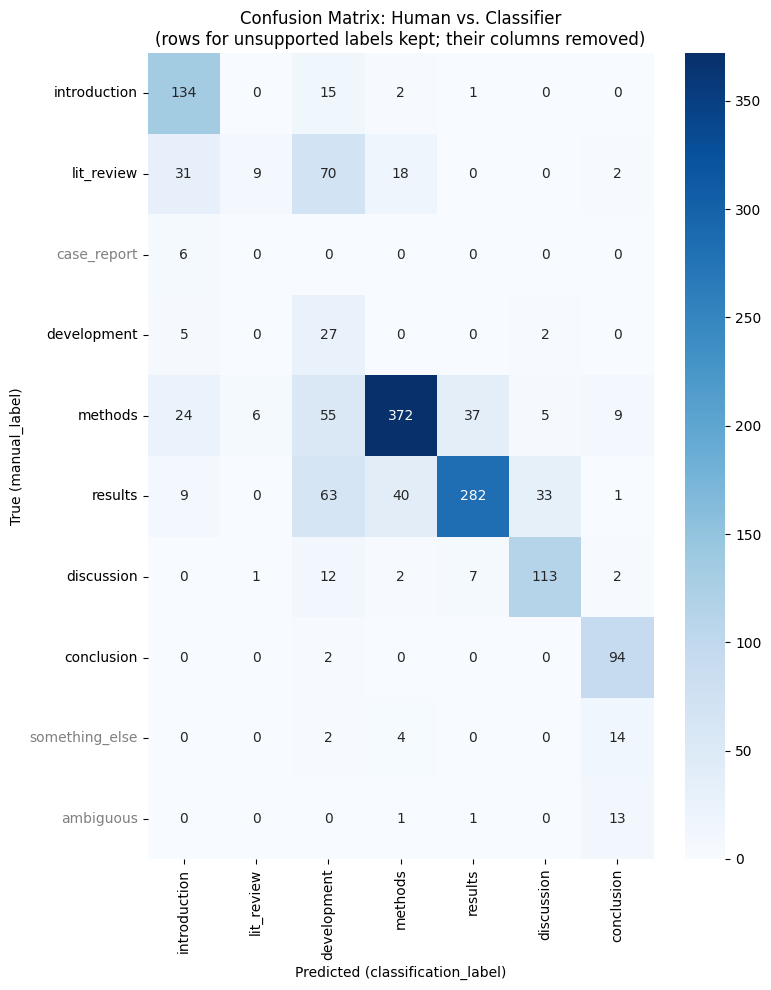

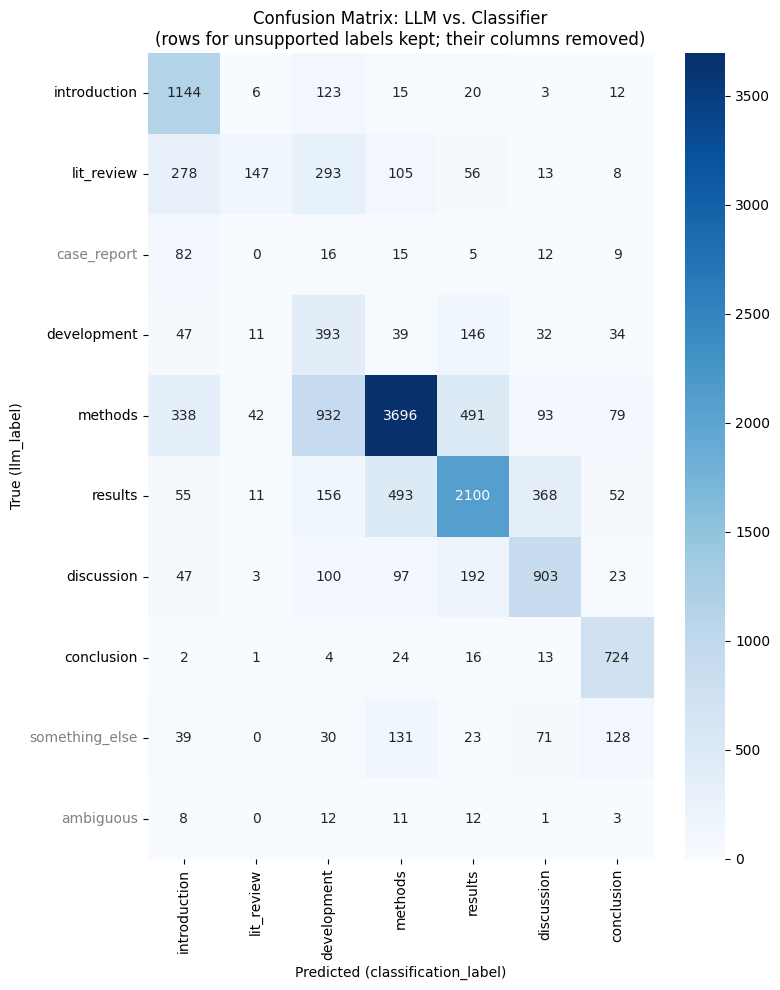

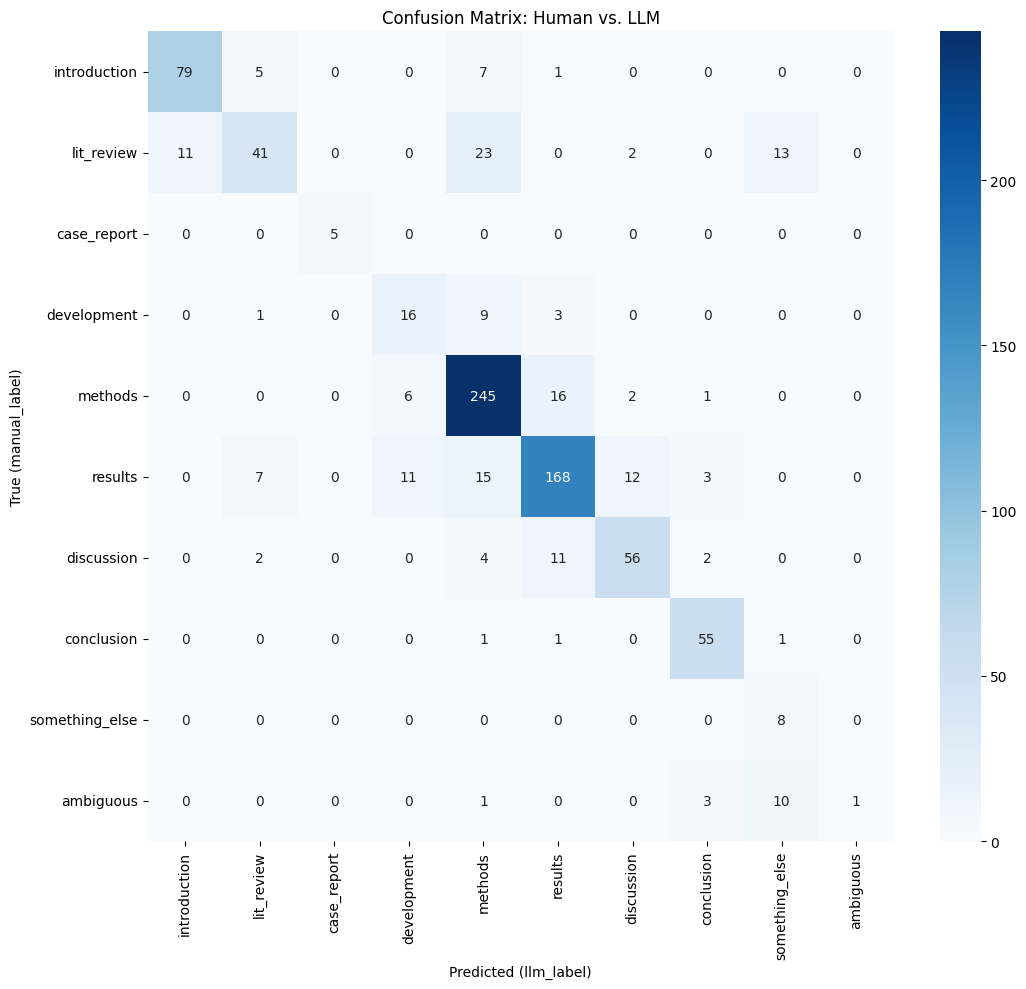

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(df, true_col, pred_col, title, pred_unsupported_cols=None):
    """
    Plot a confusion matrix.

    pred_unsupported_cols: list of labels to exclude from the predicted axis (columns)
        but keep on the true axis (rows), e.g. labels the classifier never predicted.
        Those rows are retained so it's visible where those true labels ended up.
    """
    df = df.dropna(subset=[true_col, pred_col])

    # Row labels: all present in either column, in master order
    present = set(df[true_col].unique()) | set(df[pred_col].unique())
    row_labels = [l for l in MASTER_LABEL_ORDER if l in present]

    # Column labels: exclude unsupported ones if specified
    excluded = set(pred_unsupported_cols or [])
    col_labels = [l for l in row_labels if l not in excluded]

    cm = confusion_matrix(df[true_col], df[pred_col], labels=row_labels)
    cm_df = pd.DataFrame(cm, index=row_labels, columns=row_labels)

    # Drop the excluded columns
    cm_df = cm_df[[c for c in col_labels]]

    note = "\n(rows for unsupported labels kept; their columns removed)" if excluded else ""
    fig_w = max(8, len(col_labels) * 1.1)
    fig_h = max(6, len(row_labels) * 1.0)
    plt.figure(figsize=(fig_w, fig_h))
    ax = sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')

    # Grey out row tick labels for unsupported labels
    for tick in ax.get_yticklabels():
        if tick.get_text() in excluded:
            tick.set_color('grey')

    plt.title(f'Confusion Matrix: {title}{note}')
    plt.ylabel(f'True ({true_col})')
    plt.xlabel(f'Predicted ({pred_col})')
    plt.tight_layout()
    plt.show()

# For comparisons involving the classifier as predicted: drop unsupported columns
plot_confusion_matrix(eval_df, 'manual_label', ALGORITHM_LABEL_COL, "Human vs. Classifier",
                      pred_unsupported_cols=CLASSIFIER_UNSUPPORTED_LABELS)
plot_confusion_matrix(eval_df, 'llm_label',    ALGORITHM_LABEL_COL,  "LLM vs. Classifier",
                      pred_unsupported_cols=CLASSIFIER_UNSUPPORTED_LABELS)

# For human vs. LLM: both had all labels, so show full matrix
plot_confusion_matrix(eval_df, 'manual_label', 'llm_label', "Human vs. LLM")


### Per-label F1 agreement heatmap

Symmetric F1-score per label for each rater pair. Classifier-unsupported labels are excluded so the scale is consistent with the Alpha values above.

  Excluded 625 rows containing unsupported labels ['something_else', 'ambiguous', 'case_report']
  Excluded 41 rows containing unsupported labels ['something_else', 'ambiguous', 'case_report']
  Excluded 608 rows containing unsupported labels ['something_else', 'ambiguous', 'case_report']


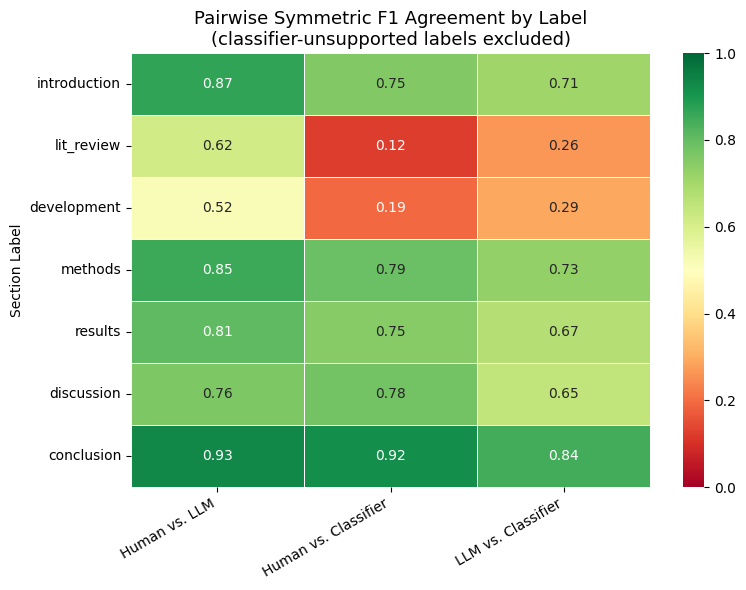

In [17]:
def calculate_per_label_agreement(df, annotator1_col, annotator2_col):
    """Symmetric F1 agreement per label, unsupported labels excluded."""
    df = filter_for_metrics(df, annotator1_col, annotator2_col)
    df = df.dropna(subset=[annotator1_col, annotator2_col])

    skip = {'accuracy', 'macro avg', 'weighted avg'}
    r1 = classification_report(df[annotator1_col], df[annotator2_col], output_dict=True, zero_division=0)
    r2 = classification_report(df[annotator2_col], df[annotator1_col], output_dict=True, zero_division=0)

    df1 = pd.DataFrame({'f1_A': {k: v['f1-score'] for k, v in r1.items() if k not in skip}})
    df2 = pd.DataFrame({'f1_B': {k: v['f1-score'] for k, v in r2.items() if k not in skip}})

    out = pd.concat([df1, df2], axis=1).fillna(0)
    out['f1_agreement_score'] = out.mean(axis=1)
    return out.reindex(METRICS_LABEL_ORDER).dropna()[['f1_agreement_score']]

comparison_df = pd.DataFrame({
    'Human vs. LLM':        calculate_per_label_agreement(eval_df, 'manual_label', 'llm_label')['f1_agreement_score'],
    'Human vs. Classifier': calculate_per_label_agreement(eval_df, 'manual_label', ALGORITHM_LABEL_COL)['f1_agreement_score'],
    'LLM vs. Classifier':   calculate_per_label_agreement(eval_df, 'llm_label',    ALGORITHM_LABEL_COL)['f1_agreement_score'],
})

plt.figure(figsize=(8, 6))
sns.heatmap(comparison_df, annot=True, fmt=".2f", cmap='RdYlGn', vmin=0.0, vmax=1.0, linewidths=.5)
plt.title('Pairwise Symmetric F1 Agreement by Label\n(classifier-unsupported labels excluded)', fontsize=13)
plt.xticks(rotation=30, ha="right")
plt.ylabel('Section Label')
plt.tight_layout()
plt.show()
